# Load Dataset

## Load NAB time series

In [1]:
## Imports
import pandas as pd
import numpy as np


In [2]:
import os

# Path to Numeta Anomoly Benchmark (NAB) data folder
base_path = "../data/NAB-master/data/realKnownCause/"

# Load one example file
file_path = os.path.join(base_path, "ambient_temperature_system_failure.csv")
df = pd.read_csv(file_path)

df.head()


,timestamp,value
0,2013-07-04 00:00:00,69.880835
1,2013-07-04 01:00:00,71.220227
2,2013-07-04 02:00:00,70.877805
3,2013-07-04 03:00:00,68.959400
4,2013-07-04 04:00:00,69.283551


## Load Anomaly Labels (JSON)

In [3]:
import json  # to work with JSON files

# Tell Python where the labels file is
label_path = "../data/NAB-master/labels/combined_labels.json"

# Open the file and read its contents
with open(label_path, "r") as label_file:      # "r" = read mode, label_file = name for the opened file
    labels = json.load(label_file)             # turn the JSON into a Python dictionary called 'labels'

# 3. Shows the first 10 dataset keys names to confirm it loaded correctly
list(labels.keys())[:10]



['artificialNoAnomaly/art_daily_no_noise.csv',
 'artificialNoAnomaly/art_daily_perfect_square_wave.csv',
 'artificialNoAnomaly/art_daily_small_noise.csv',
 'artificialNoAnomaly/art_flatline.csv',
 'artificialNoAnomaly/art_noisy.csv',
 'artificialWithAnomaly/art_daily_flatmiddle.csv',
 'artificialWithAnomaly/art_daily_jumpsdown.csv',
 'artificialWithAnomaly/art_daily_jumpsup.csv',
 'artificialWithAnomaly/art_daily_nojump.csv',
 'artificialWithAnomaly/art_increase_spike_density.csv']

## Extract Labels for Selected Dataset

In [4]:
# Select the correct dataset key from the labels dictionary
dataset_key = "realKnownCause/ambient_temperature_system_failure.csv"

# Extract the list of anomaly timestamps for this dataset
label_times = labels[dataset_key]

# Display the timestamps
label_times


['2013-12-22 20:00:00', '2014-04-13 09:00:00']

## Add Labels to DataFrame

In [5]:
# Make sure the timestamp column is in datetime format
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Converting the label timestamps into datetime objects 
label_times_dt = pd.to_datetime(label_times)

# Create a new column: 1 if the timestamp is an anomaly, 0 otherwise
df["is_anomaly"] = df["timestamp"].isin(label_times_dt).astype(int)

# See the updated dataframe
df.head()


,timestamp,value,is_anomaly
0,2013-07-04 00:00:00,69.880835,0
1,2013-07-04 01:00:00,71.220227,0
2,2013-07-04 02:00:00,70.877805,0
3,2013-07-04 03:00:00,68.959400,0
4,2013-07-04 04:00:00,69.283551,0


# Explore Structure 

## Explore Dataset Structure

In [6]:
# View first rows 
df.head()  

,timestamp,value,is_anomaly
0,2013-07-04 00:00:00,69.880835,0
1,2013-07-04 01:00:00,71.220227,0
2,2013-07-04 02:00:00,70.877805,0
3,2013-07-04 03:00:00,68.959400,0
4,2013-07-04 04:00:00,69.283551,0


In [7]:
# View last rows
df.tail()

,timestamp,value,is_anomaly
7262,2014-05-28 11:00:00,72.370206,0
7263,2014-05-28 12:00:00,72.172956,0
7264,2014-05-28 13:00:00,72.046565,0
7265,2014-05-28 14:00:00,71.825226,0
7266,2014-05-28 15:00:00,72.584089,0


In [8]:
# Check for missing values
df.isnull().sum()


timestamp     0
value         0
is_anomaly    0
dtype: int64

In [9]:
# Basic structure and summary statistics

row_count = len(df)
column_names = df.columns.tolist()
data_types = df.dtypes

print("Number of rows:", row_count)
print("Columns:", column_names)
print("\nData types:")
print(data_types)

# Summary statistics for the temperature values
temperature_summary = df["value"].describe()
print("\nSummary statistics for temperature values:")
print(temperature_summary)


Number of rows: 7267
Columns: ['timestamp', 'value', 'is_anomaly']

Data types:
timestamp     datetime64[ns]
value                float64
is_anomaly             int64
dtype: object

Summary statistics for temperature values:
count    7267.000000
mean       71.242433
std         4.247509
min        57.458406
25%        68.369411
50%        71.858493
75%        74.430958
max        86.223213
Name: value, dtype: float64


## Check Time Index and Sampling Regularity

In [10]:
#  Check time index and sampling regularity 

from IPython.display import display

# Ensure sorted by time and clean index
df = df.sort_values("timestamp").reset_index(drop=True)

# Time differences between readings
time_differences = df["timestamp"].diff()

# First 10 time differences as a small table
first_differences = time_differences.head(10).reset_index()
first_differences.columns = ["row_index", "time_gap"]

# Top 10 unique time gaps with counts as a table
gap_counts = time_differences.value_counts().reset_index()
gap_counts.columns = ["time_gap", "count"]

print("First 10 time differences:")
display(first_differences)

print("\nTop 10 Unique time differences and their counts:")
display(gap_counts.head(10))

# Check for duplicated timestamps
duplicate_timestamp_count = df["timestamp"].duplicated().sum()
print(f"\nNumber of duplicated timestamps: {duplicate_timestamp_count}")


First 10 time differences:


,row_index,time_gap
0,0,NaT
1,1,0 days 01:00:00
2,2,0 days 01:00:00
3,3,0 days 01:00:00
4,4,0 days 01:00:00
5,5,0 days 01:00:00
6,6,0 days 01:00:00
7,7,0 days 01:00:00
8,8,0 days 01:00:00
9,9,0 days 01:00:00



Top 10 Unique time differences and their counts:


,time_gap,count
0,0 days 01:00:00,7256
1,0 days 02:00:00,1
2,1 days 08:00:00,1
3,2 days 00:00:00,1
4,6 days 16:00:00,1
5,4 days 00:00:00,1
6,2 days 23:00:00,1
7,1 days 06:00:00,1
8,0 days 03:00:00,1
9,0 days 15:00:00,1



Number of duplicated timestamps: 0


# Visualise Sample

## Visualise Time Series with Anomaly Markers

In [11]:
#plotting figures
import matplotlib.pyplot as plt 

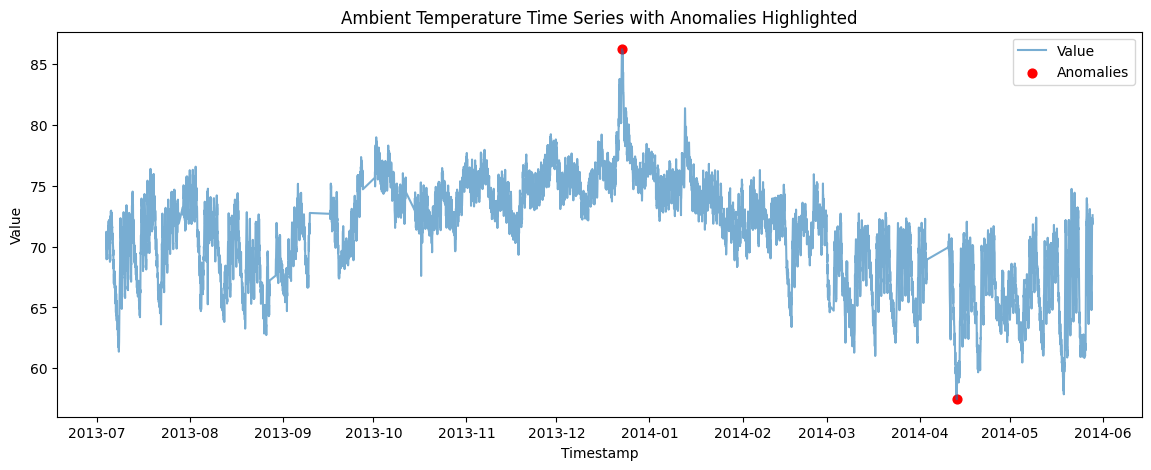

In [12]:
# Make the figure wider so it's easier to read
plt.figure(figsize=(14, 5))

# Plot the main time series
plt.plot(df["timestamp"], df["value"], label="Value", alpha=0.6)

# Select only the anomaly rows (where is_anomaly == 1)
anomaly_points = df[df["is_anomaly"] == 1]

# Plot the anomaly points as red dots on top of the line
plt.scatter(
    anomaly_points["timestamp"],
    anomaly_points["value"],
    label="Anomalies",
    color="red",
    s=40
)

# Add basic labels and legend
plt.title("Ambient Temperature Time Series with Anomalies Highlighted")
plt.xlabel("Timestamp")
plt.ylabel("Value")
plt.legend()

plt.show()


## Zoom into Each Anomaly Region

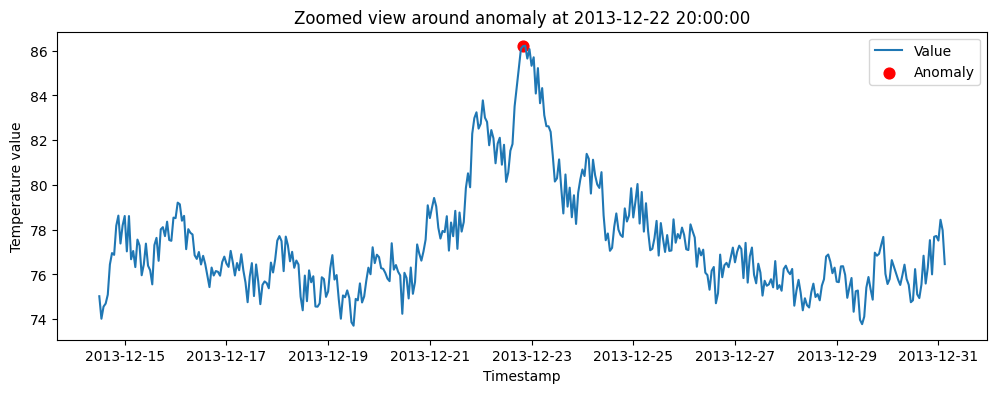

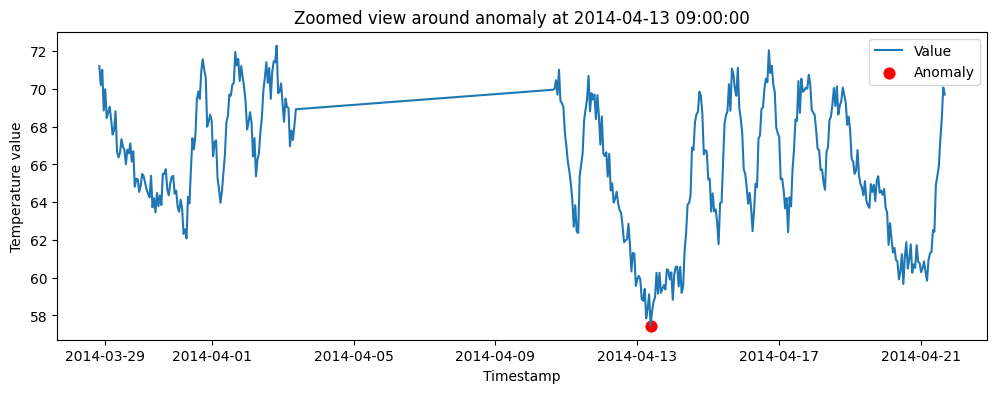

In [13]:
window_size = 200  # number of data points before and after the anomaly

for anomaly_time in label_times_dt:
    # Find the index (row number) where the timestamp equals this anomaly time
    anomaly_index = df.index[df["timestamp"] == anomaly_time][0]
    
    # Define the index range for zooming around the anomaly
    start_index = max(0, anomaly_index - window_size)
    end_index = min(len(df), anomaly_index + window_size)
    
    # Create a new figure
    plt.figure(figsize=(12, 4))
    
    # Plot the zoomed time window
    plt.plot(
        df["timestamp"].iloc[start_index:end_index],
        df["value"].iloc[start_index:end_index],
        label="Value"
    )
    
    # Plot the anomaly point itself
    plt.scatter(
        [anomaly_time],                             # x = the anomaly timestamp
        df.loc[df["timestamp"] == anomaly_time, "value"],  # y = its value
        color="red",
        s=60,                                       # marker size
        label="Anomaly"
    )
    
    plt.title(f"Zoomed view around anomaly at {anomaly_time}")
    plt.xlabel("Timestamp")
    plt.ylabel("Temperature value")
    plt.legend()
    plt.show()
